In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
df = pd.read_csv("RUN_dataset.csv")
df.head()

,top_proj,top_proj_target,top_proj_source,occ_proj,occ_proj_target,occ_proj_source,top_ms,top_ms_target,top_ms_source,occ_ms,...,num_leads_left,num_leads_right,total_files_changed,total_files_right,total_chunks_left,total_chunks_right,total_commits_left,total_commits_right,total_code_churn,has_conflict
0,2,1,1,0,0,0,2,1,1,0,...,1,1,1,1,1,2,1,1,10,0
1,0,0,0,1,0,1,1,1,0,0,...,0,1,0,1,0,1,0,1,4,0
2,1,1,0,0,0,0,1,1,1,0,...,1,0,7,0,117,0,14,0,216,0
3,1,1,0,2,1,1,1,0,0,2,...,1,1,24,6,99,6,3,1,981,0
4,0,0,0,3,2,1,1,0,0,2,...,1,1,7,2,13,3,5,1,114,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7900 entries, 0 to 7899
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   top_proj             7900 non-null   int64
 1   top_proj_target      7900 non-null   int64
 2   top_proj_source      7900 non-null   int64
 3   occ_proj             7900 non-null   int64
 4   occ_proj_target      7900 non-null   int64
 5   occ_proj_source      7900 non-null   int64
 6   top_ms               7900 non-null   int64
 7   top_ms_target        7900 non-null   int64
 8   top_ms_source        7900 non-null   int64
 9   occ_ms               7900 non-null   int64
 10  occ_ms_target        7900 non-null   int64
 11  occ_ms_source        7900 non-null   int64
 12  devs                 7900 non-null   int64
 13  devs_target          7900 non-null   int64
 14  devs_source          7900 non-null   int64
 15  devs_both            7900 non-null   int64
 16  files                790

In [4]:
X = df.drop(columns=["has_conflict"]).values
y = df["has_conflict"].values

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [6]:
# function to split data into train valid test datasets
def split_data(X, y, train_ratio=0.7, valid_ratio=0.15, test_ratio=0.15):
    assert train_ratio + valid_ratio + test_ratio == 1, "Ratios must sum to 1."
    
    dataset = TensorDataset(X, y)
    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    valid_size = int(valid_ratio * total_size)
    test_size = total_size - train_size - valid_size  # Ensures sum equals total
    
    train_data, valid_data, test_data = random_split(dataset, [train_size, valid_size, test_size])
    return train_data, valid_data, test_data

In [7]:
# prepare dataset and dataloader
train_dataset, valid_dataset, test_dataset =split_data(X_tensor,y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
# classifer
class MergeConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(MergeConflictPredictor, self).__init__()
        self.fc1 = nn.Linear(input_size, 128*2)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128*2, 64*2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64*2, 32*2)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32*2, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

In [9]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
# inti
input_size = X.shape[1]  # Number of features
model = MergeConflictPredictor(input_size).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005)
print(model)

MergeConflictPredictor(
  (fc1): Linear(in_features=41, out_features=256, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [11]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10, device="cpu"):
    model.to(device)
    train_losses, valid_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        train_losses.append(total_loss / len(train_loader))
        
        # Validation step
        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in valid_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                valid_loss += loss.item()
        
        valid_losses.append(valid_loss / len(valid_loader))
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, "
              f"Valid Loss: {valid_losses[-1]:.4f}")
    
    # Plot training and validation loss curves
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs + 1), valid_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

Epoch 1/80, Train Loss: 0.6623, Valid Loss: 0.6079
Epoch 2/80, Train Loss: 0.5216, Valid Loss: 0.4410
Epoch 3/80, Train Loss: 0.4125, Valid Loss: 0.3866
Epoch 4/80, Train Loss: 0.3756, Valid Loss: 0.3635
Epoch 5/80, Train Loss: 0.3535, Valid Loss: 0.3469
Epoch 6/80, Train Loss: 0.3359, Valid Loss: 0.3295
Epoch 7/80, Train Loss: 0.3185, Valid Loss: 0.3133
Epoch 8/80, Train Loss: 0.3030, Valid Loss: 0.3001
Epoch 9/80, Train Loss: 0.2886, Valid Loss: 0.2903
Epoch 10/80, Train Loss: 0.2760, Valid Loss: 0.2781
Epoch 11/80, Train Loss: 0.2646, Valid Loss: 0.2695
Epoch 12/80, Train Loss: 0.2534, Valid Loss: 0.2599
Epoch 13/80, Train Loss: 0.2425, Valid Loss: 0.2530
Epoch 14/80, Train Loss: 0.2333, Valid Loss: 0.2475
Epoch 15/80, Train Loss: 0.2253, Valid Loss: 0.2413
Epoch 16/80, Train Loss: 0.2162, Valid Loss: 0.2346
Epoch 17/80, Train Loss: 0.2099, Valid Loss: 0.2290
Epoch 18/80, Train Loss: 0.2031, Valid Loss: 0.2286
Epoch 19/80, Train Loss: 0.1977, Valid Loss: 0.2225
Epoch 20/80, Train Lo

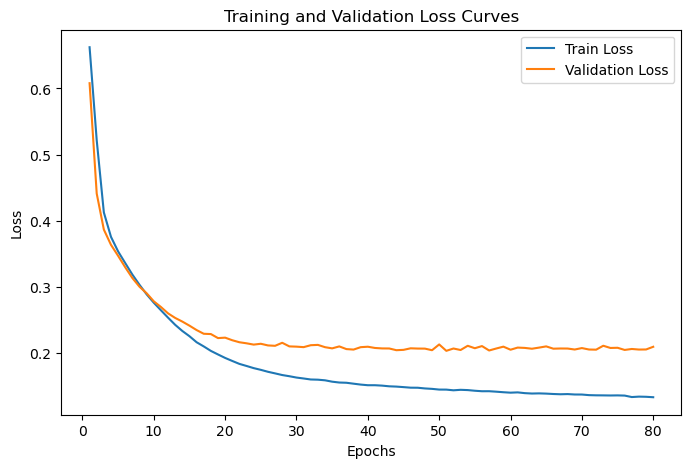

Total training time: 50.02 seconds


In [12]:
# Train the model
start_time = time.time()
train_model(model, train_loader,valid_loader, criterion, optimizer, epochs=80)
end_time = time.time()

elapsed_time = end_time - start_time

print(f"Total training time: {elapsed_time:.2f} seconds")

In [13]:
# Function to evaluate the model
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            predictions = (outputs > 0.5).float()  # Convert probabilities to binary predictions
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Conflict", "Conflict"], yticklabels=["No Conflict", "Conflict"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

Accuracy: 0.9350
Precision: 0.9005
Recall: 0.9819
F1 Score: 0.9394


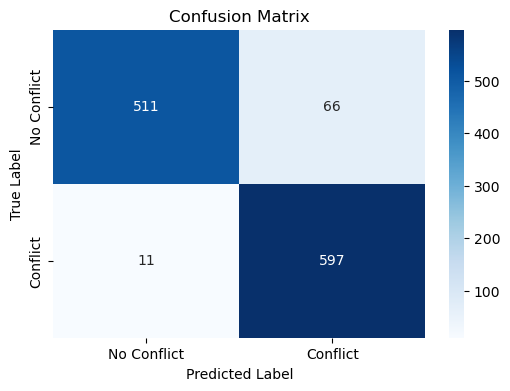

In [14]:
model = model.to(device)
evaluate_model(model, test_loader)

# **Comparison of Random Undersampling and SMOTE with MLP**

## **1. Random Undersampling (RUS) with MLP**
- **Accuracy:** 93.67%  
- **Precision:** 90.51%  
- **Recall:** 97.44%  
- **F1 Score:** 93.85%  

### **Observations:**
- Achieved high accuracy and balanced precision-recall.
- The model generalized well to both classes.
- Effective at mitigating class imbalance without introducing synthetic data.

---

## **2. SMOTE Oversampling with MLP**
- **Accuracy:** 93.2%  
- **Precision:** 42%  
- **Recall:** 90.70%  
- **F1 Score:** 57.42%  

### **Observations:**
- High recall but very low precision.
- SMOTE generated synthetic minority samples, possibly introducing noise.
- Model likely overfits to synthetic data, leading to poor generalization.

---

## **Conclusion**
- **Random Undersampling (RUS)** performed significantly better, with a balanced precision-recall and a high F1 score.  
- **SMOTE** struggled with precision, likely due to synthetic data affecting model learning.  
- For this dataset and model (MLP), **undersampling is the better approach** to handle class imbalance.
